In [ ]:
!pip install transformers datasets evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Load IMDB sentiment dataset
dataset = load_dataset("imdb")

# Use smaller data for faster Colab training
train_data = dataset["train"].shuffle(seed=42).select(range(2500))
test_data = dataset["test"].shuffle(seed=42).select(range(700))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# Load BERT tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Tokenize text reviews
def tokenize_data(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


train_data = train_data.map(tokenize_data, batched=True)
test_data = test_data.map(tokenize_data, batched=True)

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

In [ ]:
# Rename label column for Trainer
train_data = train_data.rename_column("label", "labels")
test_data = test_data.rename_column("label", "labels")

In [ ]:
# Convert dataset to PyTorch format
train_data.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_data.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [ ]:
# Load pre-trained DistilBERT model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
accuracy_metric = evaluate.load("accuracy")

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_sentiment_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

In [ ]:
# Create Trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.387749,0.413161,0.822857
2,0.308922,0.535987,0.821429


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=626, training_loss=0.35641092766588106, metrics={'train_runtime': 78.4128, 'train_samples_per_second': 63.765, 'train_steps_per_second': 7.983, 'total_flos': 165584248320000.0, 'train_loss': 0.35641092766588106, 'epoch': 2.0})

In [ ]:
# Evaluate model
eval_result = trainer.evaluate()
print("Evaluation Result:")
print(eval_result)

Evaluation Result:
{'eval_loss': 0.5359872579574585, 'eval_accuracy': 0.8214285714285714, 'eval_runtime': 2.8862, 'eval_samples_per_second': 242.536, 'eval_steps_per_second': 30.49, 'epoch': 2.0}


In [ ]:
predictions = trainer.predict(test_data)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

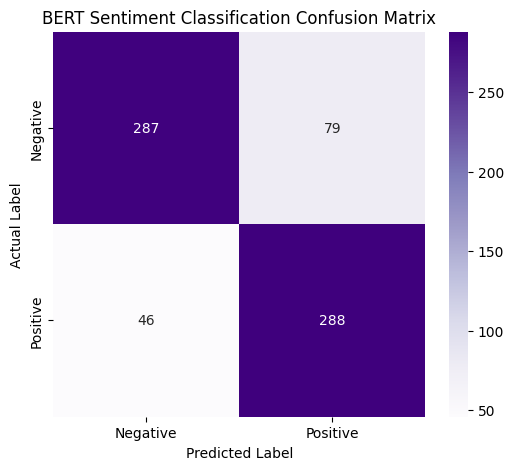

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("BERT Sentiment Classification Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
# Classification report
print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.78      0.82       366
    Positive       0.78      0.86      0.82       334

    accuracy                           0.82       700
   macro avg       0.82      0.82      0.82       700
weighted avg       0.83      0.82      0.82       700



In [ ]:
# Function for custom sentiment prediction
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        output = model(**inputs)

    probabilities = torch.softmax(output.logits, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][predicted_class].item()

    if predicted_class == 1:
        label = "Positive"
    else:
        label = "Negative"

    print("Text:", text)
    print("Predicted Sentiment:", label)
    print("Confidence:", confidence)

In [ ]:
# Test custom predictions
predict_sentiment("This movie was amazing and emotional.")
predict_sentiment("The movie was boring and disappointing.")

Text: This movie was amazing and emotional.
Predicted Sentiment: Positive
Confidence: 0.9836873412132263
Text: The movie was boring and disappointing.
Predicted Sentiment: Negative
Confidence: 0.9857893586158752


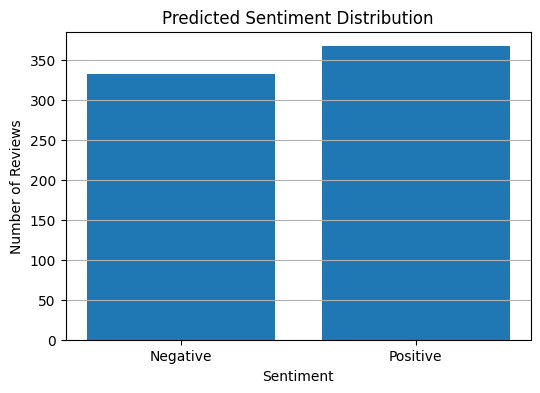

In [ ]:
# Visualize prediction distribution
unique, counts = np.unique(y_pred, return_counts=True)

plt.figure(figsize=(6, 4))
plt.bar(["Negative", "Positive"], counts)
plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.grid(axis="y")
plt.show()